In [96]:
!pip install pandas seaborn matplotlib numpy statsmodels

In [97]:
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.linear_model import LogisticRegression

HEALTHY, UNHEALTHY = "#4477AA", "#EE6677"  # colorblind-safe pair, fixed per class
RANDOM_STATE = 42 # seed for a random number generator

## 1. Load data

Load the data from GrimoireLab and build a dataframe with the git reposites that were classified

In [98]:

with open('../data/metrics.json', 'r') as f:
    data = json.load(f)

records = []
for spdx_id, info in data['packages'].items():
    row = dict(info["metrics"])
    row["SPDXID"] = spdx_id
    row["repository"] = info["repository"]
    records.append(row)
df_metrics = pd.DataFrame(records)

df_expert = pd.read_csv("../data/expert-classification.csv")
df_expert = df_expert[df_expert["Result"].isin(["Healthy", "Unhealthy"])]

df = df_expert[["SPDXID", "name", "Result"]].merge(df_metrics, on="SPDXID", how="inner")

print(f"Packages with metrics: {len(df_metrics)}")
print(f"Packages classified as healthy/unhealthy by the expert: {len(df_expert)}\n")
print(df["Result"].value_counts())
print("\nMetrics collected from", data["metadata"]["configuration"]["from_date"],
      "to", data["metadata"]["configuration"]["to_date"])

Packages with metrics: 200
Packages classified as healthy/unhealthy by the expert: 166

Result
Healthy      89
Unhealthy    77
Name: count, dtype: int64

Metrics collected from 2025-01-01T00:00:00 to 2026-06-19T00:00:00


In [99]:
META_COLS = ["SPDXID", "name", "Result", "repository"]
metric_cols = [c for c in df.columns if c not in META_COLS]


# converts True/False to 1.0, we have to do this before the cols are removed
# and we use it to analyze the correlations
y = (df["Result"] == "Unhealthy").astype(int)

df[metric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
total_commits,166.0,26.885542,84.851843,0.0,0.000000,2.000000,20.750000,930.000000
total_contributors,166.0,3.421687,7.451045,0.0,0.000000,1.000000,3.750000,57.000000
total_organizations,166.0,1.849398,3.038376,0.0,0.000000,1.000000,2.750000,24.000000
pony_factor,166.0,0.759036,0.928868,0.0,0.000000,1.000000,1.000000,8.000000
elephant_factor,166.0,0.632530,0.605952,0.0,0.000000,1.000000,1.000000,2.000000
recent_organizations,166.0,1.572289,2.663596,0.0,0.000000,1.000000,2.000000,23.000000
recent_contributors,166.0,2.596386,5.328004,0.0,0.000000,1.000000,3.000000,46.000000
recent_commits,166.0,21.198795,68.920791,0.0,0.000000,1.000000,14.500000,725.000000
contributor_growth,166.0,0.343373,2.562465,-9.0,0.000000,0.000000,1.000000,16.000000
contributor_growth_rate,166.0,0.300513,1.122160,-1.0,0.000000,0.000000,0.333333,8.000000


## 2. Redundant metrics

We remove metrics in three passes:

1. No information: constant (or almost constant) across packages.
2. Derived metrics: values that are a fixed transformation of another metric.
3. Highly correlated metrics (|Pearson| > 0.8 on the log scale). Within each correlated group we
   keep the metric that separates Healthy from Unhealthy best on its own (univariate ROC AUC), so
   the choice of the "winner" does not depend on column order.

In [100]:
# 2.1 Constant / near-constant metrics
# These indicators are artifacts, not metrics

n_unique = df[metric_cols].nunique()
n_nonzero = (df[metric_cols] != 0).sum()
uninformative = sorted(set(n_unique[n_unique <= 1].index) | set(n_nonzero[n_nonzero <= 1].index))
print("Constant or almost constant:")
print(pd.DataFrame({"unique_values": n_unique[uninformative], "non_zero_rows": n_nonzero[uninformative]}))

Constant or almost constant:
                     unique_values  non_zero_rows
file_types_binary                2              1
found_file_adopters              1              0


In [101]:
# 2.2 Derived metrics
# values that are a fixed transformation of another metric (redundant), this makes the heatmap below simpler

print("corr(total_commits, commits_per_year) =", round(df["total_commits"].corr(df["commits_per_year"]), 4))
print("corr(commits_per_week, commits_per_month) =", round(df["commits_per_week"].corr(df["commits_per_month"]), 4))
print("corr(message_size_mean, message_size_median) =", round(df["message_size_mean"].corr(df["message_size_median"]), 4))
print("corr(commit_size_added_lines, commit_size_removed_lines) =",
      round(df["commit_size_added_lines"].corr(df["commit_size_removed_lines"]), 4))

derived = [
    "commits_per_week", "commits_per_month", "commits_per_year",  # total_commits divided by the window
    "message_size_median",                                        # ~ message_size_mean
    "commit_size_removed_lines",                                  # ~ commit_size_added_lines
]

corr(total_commits, commits_per_year) = 1.0
corr(commits_per_week, commits_per_month) = 1.0
corr(message_size_mean, message_size_median) = 0.8362
corr(commit_size_added_lines, commit_size_removed_lines) = 0.905


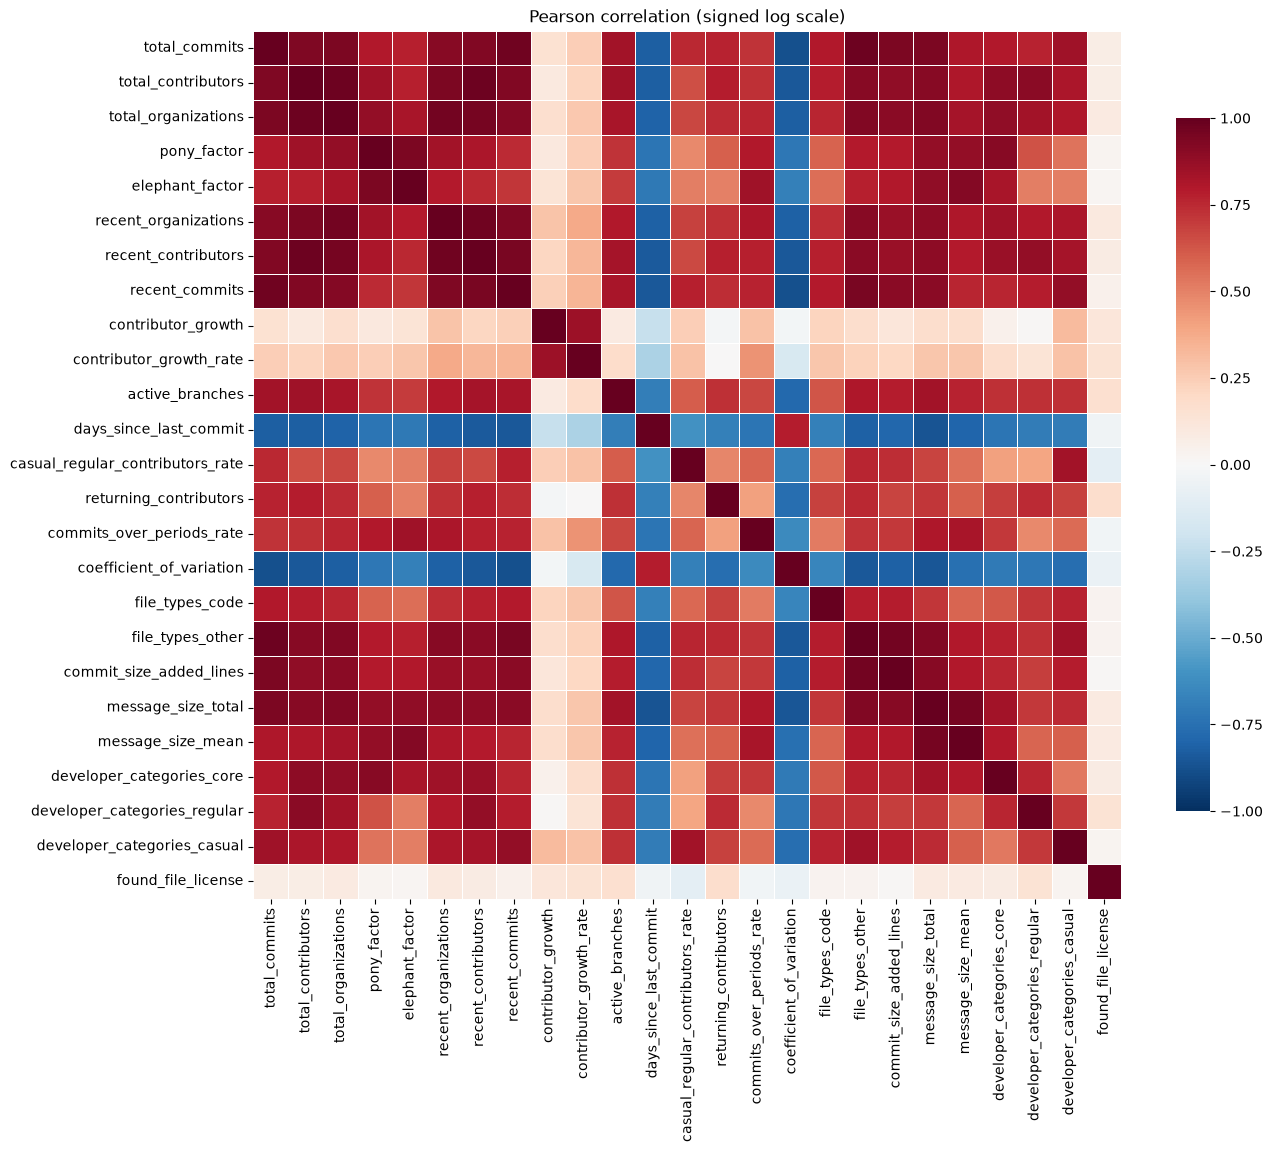

In [102]:
# 2.3 Correlated metrics

def signed_log1p(x):
    """A log transformation to prepare data for the pearson correlation.
    """ 
    return np.sign(x) * np.log1p(np.abs(x))

candidates = [c for c in metric_cols if c not in uninformative + derived]
X_log = signed_log1p(df[candidates])

corr = X_log.corr(method="pearson")
plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.75})
plt.title("Pearson correlation (signed log scale)")
plt.show()

In [103]:
THRESHOLD = 0.8

# How to read the value: AUC is the probability that a randomly chosen Unhealthy 
# package has a higher value of the metric than a randomly chosen Healthy one.
# Good when it is close to 1 (likely Unhealthy) or 0 (likely Healthy)
univariate_auc = pd.Series({c: roc_auc_score(y, df[c]) for c in candidates})
strength = (univariate_auc - 0.5).abs().sort_values(ascending=False)

selected, dropped = [], []
for metric in strength.index:
    twin = next((k for k in selected if abs(corr.loc[metric, k]) >= THRESHOLD), None)
    if twin is None:
        selected.append(metric)
    else:
        dropped.append((metric, twin, round(corr.loc[metric, twin], 2)))

print("Dropped (metric, kept twin, correlation):")
for row in dropped:
    print("  ", row)
print(f"\nSelected {len(selected)} out of {len(metric_cols)} metrics:")
pd.DataFrame({"univariate_auc": univariate_auc[selected].round(2)})

Dropped (metric, kept twin, correlation):
   ('file_types_other', 'days_since_last_commit', np.float64(-0.82))
   ('total_commits', 'days_since_last_commit', np.float64(-0.83))
   ('message_size_total', 'days_since_last_commit', np.float64(-0.86))
   ('total_contributors', 'days_since_last_commit', np.float64(-0.82))
   ('total_organizations', 'days_since_last_commit', np.float64(-0.81))
   ('pony_factor', 'developer_categories_core', np.float64(0.91))
   ('message_size_mean', 'days_since_last_commit', np.float64(-0.8))
   ('recent_contributors', 'days_since_last_commit', np.float64(-0.84))
   ('recent_commits', 'days_since_last_commit', np.float64(-0.85))
   ('recent_organizations', 'days_since_last_commit', np.float64(-0.82))
   ('elephant_factor', 'commit_size_added_lines', np.float64(0.8))
   ('coefficient_of_variation', 'commit_size_added_lines', np.float64(-0.82))
   ('casual_regular_contributors_rate', 'developer_categories_casual', np.float64(0.84))
   ('contributor_growth', 'c

,univariate_auc
days_since_last_commit,0.98
commit_size_added_lines,0.03
developer_categories_core,0.04
commits_over_periods_rate,0.07
active_branches,0.08
file_types_code,0.13
developer_categories_casual,0.21
returning_contributors,0.21
developer_categories_regular,0.23
contributor_growth_rate,0.43


## 3. Let's build the model and see how it goes

In [104]:
X = X_log[selected]
groups = df["repository"] # we don't have the values in X_log

def make_model(C=1.0):
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(C=C, max_iter=1000),
    )


# Sometimes we have the same repository twice, this is why we need grouping.
# The 10 k-fold create sets of 10 items, train with 9 and test with 1,
# it does it a way (stratified) that the sets are balanced.
cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
print(f"{X.shape[0]} packages, {X.shape[1]} features, {groups.nunique()} distinct repositories")

166 packages, 11 features, 164 distinct repositories


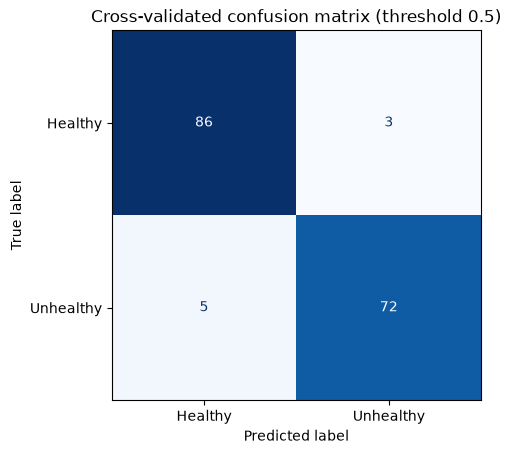

Accuracy: 95.2%    ROC AUC: 0.971

              precision    recall  f1-score   support

     Healthy       0.95      0.97      0.96        89
   Unhealthy       0.96      0.94      0.95        77

    accuracy                           0.95       166
   macro avg       0.95      0.95      0.95       166
weighted avg       0.95      0.95      0.95       166



In [105]:
score_cv = cross_val_predict(make_model(), X, y, cv=cv, groups=groups, method="predict_proba")[:, 1]
pred_cv = (score_cv >= 0.5).astype(int)

cm = confusion_matrix(y, pred_cv)
ConfusionMatrixDisplay(cm, display_labels=["Healthy", "Unhealthy"]).plot(cmap="Blues", colorbar=False)
plt.title("Cross-validated confusion matrix (threshold 0.5)")
plt.show()

print(f"Accuracy: {(pred_cv == y).mean():.1%}    ROC AUC: {roc_auc_score(y, score_cv):.3f}\n")
print(classification_report(y, pred_cv, target_names=["Healthy", "Unhealthy"]))

### When did the model failed?

In [106]:
df_scores = df[["name", "Result", "repository"]].copy()
df_scores["score"] = score_cv.round(3)
df_scores["predicted"] = np.where(pred_cv == 1, "Unhealthy", "Healthy")

misclassified = df_scores[df_scores["Result"] != df_scores["predicted"]]
misclassified.join(df[["total_commits", "recent_contributors", "days_since_last_commit"]])

,name,Result,repository,score,predicted,total_commits,recent_contributors,days_since_last_commit
10,tiny-relative-date,Healthy,https://github.com/wildlyinaccurate/relative-d...,0.503,Unhealthy,6,0,366
15,call-bound,Healthy,https://github.com/ljharb/call-bound.git,0.609,Unhealthy,4,0,472
26,cross-env,Unhealthy,https://github.com/kentcdodds/cross-env.git,0.012,Healthy,16,3,214
42,estree-walker,Unhealthy,https://github.com/Rich-Harris/estree-walker.git,0.074,Healthy,1,1,284
50,xmlbuilder,Unhealthy,https://github.com/oozcitak/xmlbuilder-js.git,0.237,Healthy,3,2,199
91,@jridgewell/sourcemap-codec,Unhealthy,https://github.com/jridgewell/sourcemaps.git,0.007,Healthy,116,3,25
133,@fastify/busboy,Healthy,https://github.com/fastify/busboy.git,0.973,Unhealthy,0,0,534
150,http-parser-js,Unhealthy,https://github.com/creationix/http-parser-js.git,0.146,Healthy,4,0,436


### The final model

The model used to score new packages is fitted on all labelled packages. The weights are on
standardised log features, so they are comparable: negative pushes towards Healthy, positive
towards Unhealthy.

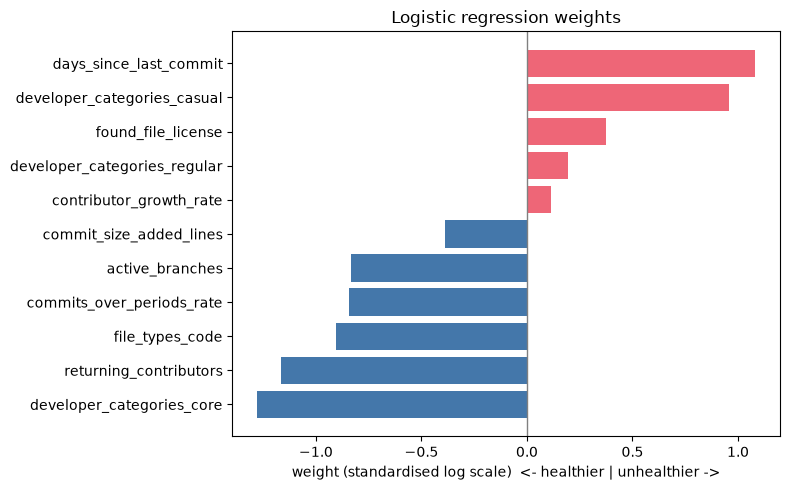

intercept: -1.023


In [108]:
model = make_model().fit(X, y)
coefs = pd.Series(model[-1].coef_[0], index=selected).sort_values()

plt.figure(figsize=(8, 5))
colors = [UNHEALTHY if c > 0 else HEALTHY for c in coefs]
plt.barh(coefs.index, coefs.values, color=colors)
plt.axvline(0, color="grey", linewidth=1)
plt.xlabel("weight (standardised log scale)  <- healthier | unhealthier ->")
plt.title("Logistic regression weights")
plt.tight_layout()
plt.show()
print("intercept:", round(model[-1].intercept_[0], 3))

In [111]:
coefs

developer_categories_core      -1.277484
returning_contributors         -1.167053
file_types_code                -0.905957
commits_over_periods_rate      -0.841944
active_branches                -0.834069
commit_size_added_lines        -0.389225
contributor_growth_rate         0.114363
developer_categories_regular    0.193106
found_file_license              0.376334
developer_categories_casual     0.958613
days_since_last_commit          1.081051
dtype: float64

### What is the distribution of the scores?

During the first iterations of the model and due to the huge amount of dead (or almost dead)
projects in npm, we find the distribution strongly bimodal. We have most of the values close 
to 0 or close to 1. Almost nothing in between.

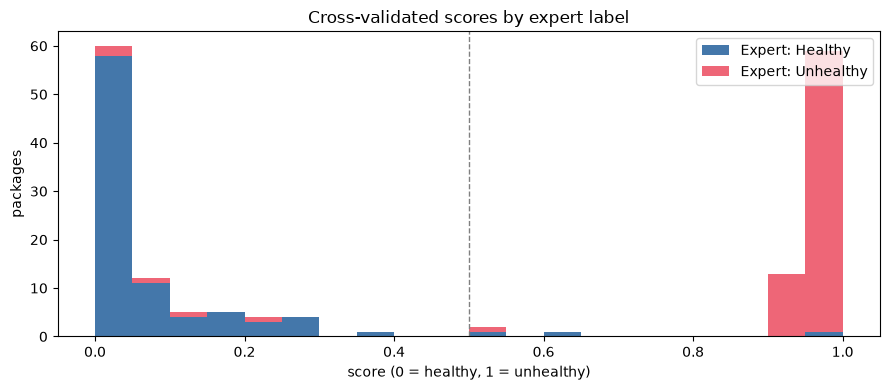

count    166.000
mean       0.462
std        0.452
min        0.000
25%        0.010
50%        0.229
75%        0.972
max        0.981
dtype: float64


In [110]:
bins = np.linspace(0, 1, 21)
plt.figure(figsize=(9, 4))
plt.hist([score_cv[y == 0], score_cv[y == 1]], bins=bins, stacked=True,
         color=[HEALTHY, UNHEALTHY], label=["Expert: Healthy", "Expert: Unhealthy"])
plt.axvline(0.5, color="grey", linestyle="--", linewidth=1)
plt.xlabel("score (0 = healthy, 1 = unhealthy)")
plt.ylabel("packages")
plt.title("Cross-validated scores by expert label")
plt.legend()
plt.tight_layout()
plt.show()

print(pd.Series(score_cv).describe().round(3))